### Experimental Setup

In [ ]:
FEATURE_SELECTION_METHOD = "PSO"
DEEP_LEARNING_CATEGORY = "Classical"
MODEL_ARCHITECTURE = "CNN"
DATASET_NAME = "Filetop"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Import Necessary Packages

In [ ]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Visualization
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
import sklearn
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    LSTM,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ============================================================
# Transformers
# ============================================================
import transformers
from transformers import (
    BertTokenizer,
    GPT2Tokenizer,
    TFBertModel,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
from flaml import AutoML
import joblib

### Load QUT-DV25 Dataset


In [ ]:
# ============================================================
# Data Loading and Initial Inspection
# ================== ==========================================

# Define the datasetfile path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_Reads,Total_Writes,Total_Read_Data_Transfer,Total_Write_Data_Transfer,Read_Processes,Write_Processes,Read_Data_Transfer_Processes,Write_Data_Transfer_Processes,File_Access_Processes,Level
0,10Cent10-999.0.4.tar.gz,1345126,711470,273890605,580106,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pgrep, pip, StreamTrans, sqld...",1
1,10Cent11-999.0.4.tar.gz,1192399,585508,251798360,547692,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pgrep, pip, sqldb:c~lite, Str...",1
2,11Cent-999.0.0.tar.gz,1083052,648800,233980925,463210,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pip, pgrep, sqldb:c~lite, Str...",1
3,11Cent-999.0.1.tar.gz,1010263,560585,211948676,448241,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pip, pgrep, sqldb:c~lite, Str...",1
4,11Cent-999.0.2.tar.gz,928456,520884,201673655,441561,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...","StreamTrans, strace, Classif~date, pip, sqldb:...","gnome-system-mo, pip, pgrep, sqldb:c~lite, Str...",1


### Clear Backend Session

In [ ]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()


### Selected Features

In [ ]:
selected_features = ['Total_Reads', 'Total_Writes', 'Total_Write_Data_Transfer', 'Read_Processes', 'Read_Data_Transfer_Processes', 'Write_Data_Transfer_Processes', 'File_Access_Processes']

### Data Preprocessing

In [ ]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

### Setup OUTPUT_DIR

In [ ]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)


#Model

In [ ]:
# ============================================================
# Define model saving configuration
# =========

MODEL_NAME = "best_model.h5"


# ==========================
# Detect categorical & numeric columns
# ==========================
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()


# ==========================
# Scale numeric features
# ==========================
if len(numeric_cols) > 0:
    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[numeric_cols])
    X_val_num   = scaler.transform(X_val[numeric_cols])
    X_test_num  = scaler.transform(X_test[numeric_cols])
else:
    X_train_num = np.empty((len(X_train), 0), dtype=np.float32)
    X_val_num   = np.empty((len(X_val), 0), dtype=np.float32)
    X_test_num  = np.empty((len(X_test), 0), dtype=np.float32)


# ==========================
# Apply TF-IDF separately per categorical column
# ==========================
processed_texts_train = []
processed_texts_val = []
processed_texts_test = []

tfidf_vectorizers = {}

for col in categorical_cols:
    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
    tfidf.fit(X_train[col].astype(str))
    tfidf_vectorizers[col] = tfidf

    processed_texts_train.append(tfidf.transform(X_train[col].astype(str)).toarray())
    processed_texts_val.append(tfidf.transform(X_val[col].astype(str)).toarray())
    processed_texts_test.append(tfidf.transform(X_test[col].astype(str)).toarray())

if len(processed_texts_train) > 0:
    X_train_text = np.concatenate(processed_texts_train, axis=1).astype(np.float32)
    X_val_text   = np.concatenate(processed_texts_val, axis=1).astype(np.float32)
    X_test_text  = np.concatenate(processed_texts_test, axis=1).astype(np.float32)
else:
    X_train_text = np.empty((len(X_train), 0), dtype=np.float32)
    X_val_text   = np.empty((len(X_val), 0), dtype=np.float32)
    X_test_text  = np.empty((len(X_test), 0), dtype=np.float32)


# ==========================
# Concatenate numeric + text features
# ==========================
X_train_processed = np.hstack([X_train_num, X_train_text]).astype(np.float32)
X_val_processed   = np.hstack([X_val_num, X_val_text]).astype(np.float32)
X_test_processed  = np.hstack([X_test_num, X_test_text]).astype(np.float32)


# ==========================
# Convert to float32 and reshape
# ==========================
X_train_dense = X_train_processed.reshape((X_train_processed.shape[0], X_train_processed.shape[1], 1))
X_val_dense   = X_val_processed.reshape((X_val_processed.shape[0], X_val_processed.shape[1], 1))
X_test_dense  = X_test_processed.reshape((X_test_processed.shape[0], X_test_processed.shape[1], 1))


# ==========================
# Ensure labels are numeric
# ==========================
y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# ==========================
# Callbacks
# ==========================
checkpoint_cb = ModelCheckpoint(MODEL_NAME, monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)
reduce_lr_cb  = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=200, verbose=1)
early_stop_cb = EarlyStopping(monitor="val_accuracy", patience=200, restore_best_weights=True)


# ==========================
# Build CNN Model
# ==========================

# Define input shape
input_shape = (X_train_dense.shape[1], 1)

# Input Layer
inputs = keras.layers.Input(shape=input_shape, name="input_layer")

# Convolutional Block 1
x = layers.Conv1D(
    filters=64,
    kernel_size=3,
    activation="relu",
    name="conv1"
)(inputs)

x = layers.MaxPooling1D(
    pool_size=2,
    name="maxpool1"
)(x)

# Convolutional Block 2
x = layers.Conv1D(
    filters=128,
    kernel_size=3,
    activation="relu",
    name="conv2"
)(x)

# Global Feature Aggregation
x = layers.GlobalMaxPooling1D(name="global_maxpool")(x)

# Fully Connected Layer
x = layers.Dense(
    units=64,
    activation="relu",
    name="fc1"
)(x)

# Output Layer
outputs = layers.Dense(
    units=1,
    activation="sigmoid",
    name="output_layer"
)(x)

# Build Model
model = keras.models.Model(
    inputs=inputs,
    outputs=outputs,
    name="CNN"
)


# ==========================
# Compile Model
# ==========================

model.compile(
    tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



### Compime the Model

In [ ]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    X_train_dense, y_train,
    validation_data=(X_val_dense, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=2
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200

Epoch 1: val_accuracy did not improve from 0.91686
2498/2498 - 19s - loss: 0.0876 - accuracy: 0.9637 - val_loss: 0.3821 - val_accuracy: 0.9131 - 19s/epoch - 8ms/step
Epoch 2/200

Epoch 2: val_accuracy did not improve from 0.91686
2498/2498 - 21s - loss: 0.0808 - accuracy: 0.9633 - val_loss: 0.3819 - val_accuracy: 0.9038 - 21s/epoch - 8ms/step
Epoch 3/200

Epoch 3: val_accuracy did not improve from 0.91686
2498/2498 - 19s - loss: 0.0869 - accuracy: 0.9619 - val_loss: 0.3871 - val_accuracy: 0.9089 - 19s/epoch - 8ms/step
Epoch 4/200

Epoch 4: val_accuracy did not improve from 0.91686
2498/2498 - 21s - loss: 0.0918 - accuracy: 0.9597 - val_loss: 0.4011 - val_accuracy: 0.9005 - 21s/epoch - 8ms/step
Epoch 5/200

Epoch 5: val_accuracy did not improve from 0.91686
2498/2498 - 21s - loss: 0.0903 - accuracy: 0.9632 - val_loss: 0.4501 - val_accuracy: 0.9010 - 21s/epoch - 8ms/step
Epoch 6/200

Epoch 6: val_accuracy did not improve from 0.91686
2498/2498 - 19s - loss: 0.0897 - accuracy

2498/2498 - 21s - loss: 0.0768 - accuracy: 0.9676 - val_loss: 0.4997 - val_accuracy: 0.9014 - 21s/epoch - 8ms/step
Epoch 47/200

Epoch 47: val_accuracy did not improve from 0.91686
2498/2498 - 19s - loss: 0.0747 - accuracy: 0.9690 - val_loss: 0.4691 - val_accuracy: 0.9010 - 19s/epoch - 8ms/step
Epoch 48/200

Epoch 48: val_accuracy did not improve from 0.91686
2498/2498 - 21s - loss: 0.0840 - accuracy: 0.9644 - val_loss: 0.4423 - val_accuracy: 0.9047 - 21s/epoch - 8ms/step
Epoch 49/200

Epoch 49: val_accuracy improved from 0.91686 to 0.91826, saving model to best_model.h5
2498/2498 - 19s - loss: 0.0698 - accuracy: 0.9693 - val_loss: 0.4295 - val_accuracy: 0.9183 - 19s/epoch - 8ms/step
Epoch 50/200

Epoch 50: val_accuracy did not improve from 0.91826
2498/2498 - 21s - loss: 0.0783 - accuracy: 0.9673 - val_loss: 0.4475 - val_accuracy: 0.9085 - 21s/epoch - 8ms/step
Epoch 51/200

Epoch 51: val_accuracy did not improve from 0.91826
2498/2498 - 19s - loss: 0.0800 - accuracy: 0.9676 - val_loss

Epoch 92/200

Epoch 92: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0692 - accuracy: 0.9708 - val_loss: 0.4375 - val_accuracy: 0.9061 - 8s/epoch - 3ms/step
Epoch 93/200

Epoch 93: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0668 - accuracy: 0.9726 - val_loss: 0.4141 - val_accuracy: 0.8986 - 8s/epoch - 3ms/step
Epoch 94/200

Epoch 94: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0705 - accuracy: 0.9710 - val_loss: 0.4575 - val_accuracy: 0.9080 - 8s/epoch - 3ms/step
Epoch 95/200

Epoch 95: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0677 - accuracy: 0.9716 - val_loss: 0.4639 - val_accuracy: 0.9043 - 8s/epoch - 3ms/step
Epoch 96/200

Epoch 96: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0670 - accuracy: 0.9720 - val_loss: 0.4844 - val_accuracy: 0.9047 - 8s/epoch - 3ms/step
Epoch 97/200

Epoch 97: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0683 - accurac

2498/2498 - 8s - loss: 0.0617 - accuracy: 0.9761 - val_loss: 0.5599 - val_accuracy: 0.9080 - 8s/epoch - 3ms/step
Epoch 138/200

Epoch 138: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0755 - accuracy: 0.9702 - val_loss: 0.5508 - val_accuracy: 0.9113 - 8s/epoch - 3ms/step
Epoch 139/200

Epoch 139: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0629 - accuracy: 0.9756 - val_loss: 0.5568 - val_accuracy: 0.9024 - 8s/epoch - 3ms/step
Epoch 140/200

Epoch 140: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0658 - accuracy: 0.9748 - val_loss: 0.6022 - val_accuracy: 0.9043 - 8s/epoch - 3ms/step
Epoch 141/200

Epoch 141: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0619 - accuracy: 0.9753 - val_loss: 0.6016 - val_accuracy: 0.9038 - 8s/epoch - 3ms/step
Epoch 142/200

Epoch 142: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0606 - accuracy: 0.9771 - val_loss: 0.5957 - val_accuracy: 0.8996 - 8s

Epoch 183/200

Epoch 183: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0557 - accuracy: 0.9758 - val_loss: 0.5264 - val_accuracy: 0.9038 - 8s/epoch - 3ms/step
Epoch 184/200

Epoch 184: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0903 - accuracy: 0.9720 - val_loss: 0.5807 - val_accuracy: 0.9122 - 8s/epoch - 3ms/step
Epoch 185/200

Epoch 185: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0567 - accuracy: 0.9768 - val_loss: 0.5876 - val_accuracy: 0.9075 - 8s/epoch - 3ms/step
Epoch 186/200

Epoch 186: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0544 - accuracy: 0.9760 - val_loss: 0.5828 - val_accuracy: 0.9108 - 8s/epoch - 3ms/step
Epoch 187/200

Epoch 187: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.0619 - accuracy: 0.9741 - val_loss: 0.5478 - val_accuracy: 0.9099 - 8s/epoch - 3ms/step
Epoch 188/200

Epoch 188: val_accuracy did not improve from 0.91826
2498/2498 - 8s - loss: 0.05

### Clear Backend Session

In [ ]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [ ]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(X_val_dense, y_val, verbose=0)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(X_test_dense, y_test, verbose=0)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")



Training Time: 8236.08 seconds
Validation Time: 0.18 seconds
Testing Time: 0.15 seconds


### Trainig and Validation Plot

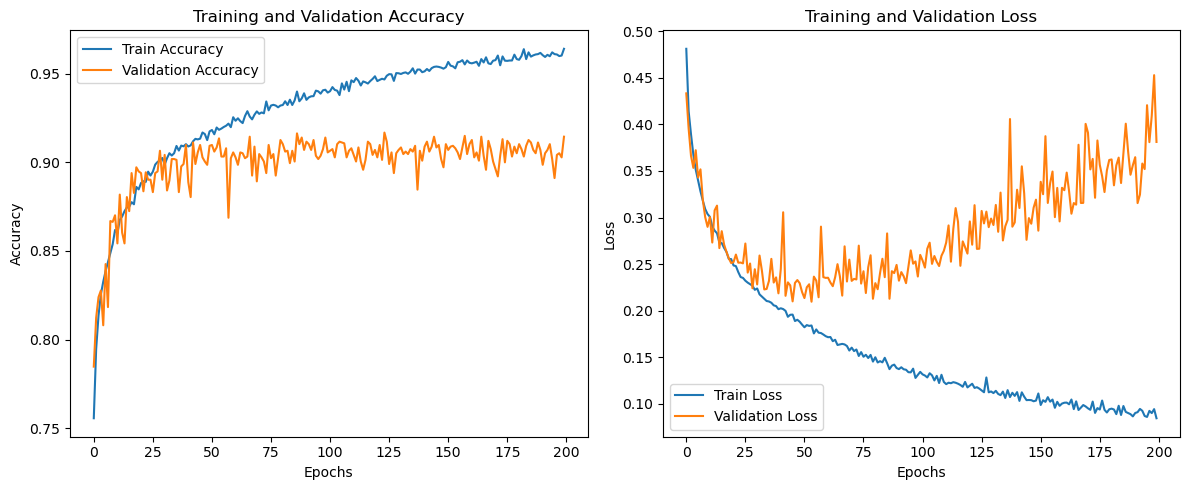

In [ ]:
# === Plot Accuracy and Loss ===
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.tight_layout()
plt.show()

### Classification Report

313/313 [==============================] - 0s 1ms/step

=== Classification Report (Train) ===
              precision    recall  f1-score   support

         0.0   0.972172  0.971200  0.971686      5000
         1.0   0.971165  0.972139  0.971652      4989

    accuracy                       0.971669      9989
   macro avg   0.971669  0.971669  0.971669      9989
weighted avg   0.971669  0.971669  0.971669      9989


=== Confusion Matrix (Train) ===


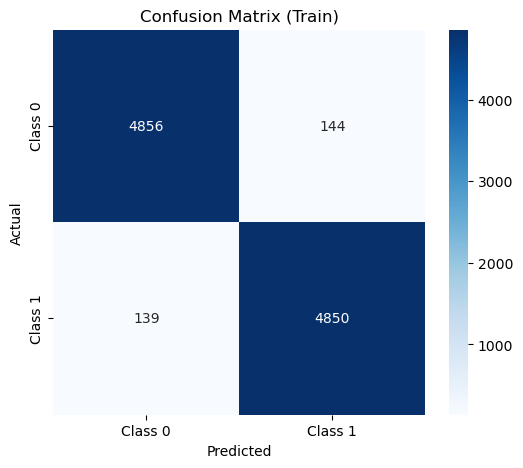

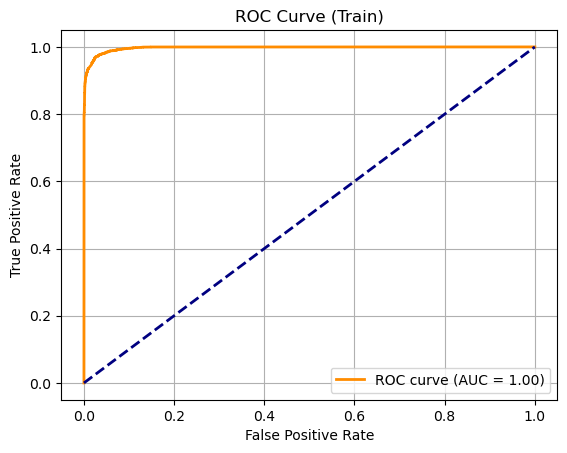

67/67 [==============================] - 0s 1ms/step

=== Classification Report (Validation) ===
              precision    recall  f1-score   support

         0.0   0.926174  0.901119  0.913475      1072
         1.0   0.903461  0.927970  0.915551      1069

    accuracy                       0.914526      2141
   macro avg   0.914818  0.914545  0.914513      2141
weighted avg   0.914834  0.914526  0.914512      2141


=== Confusion Matrix (Validation) ===


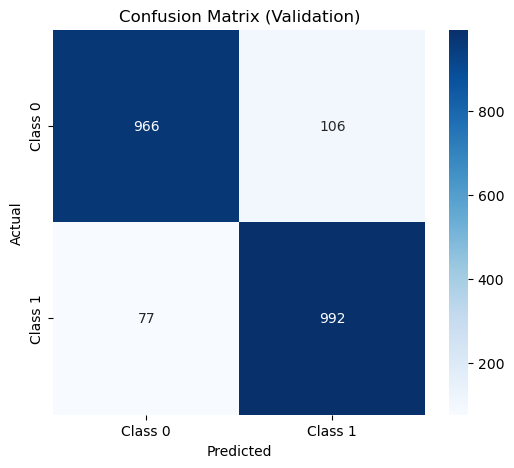

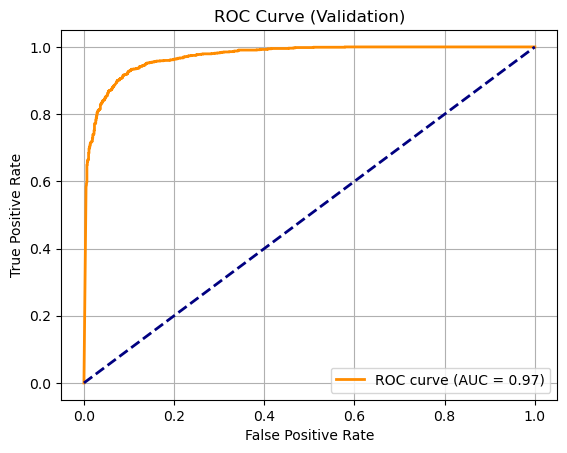

67/67 [==============================] - 0s 1ms/step

=== Classification Report (Test) ===
              precision    recall  f1-score   support

         0.0   0.914874  0.912313  0.913592      1072
         1.0   0.912313  0.914874  0.913592      1069

    accuracy                       0.913592      2141
   macro avg   0.913594  0.913594  0.913592      2141
weighted avg   0.913595  0.913592  0.913592      2141


=== Confusion Matrix (Test) ===


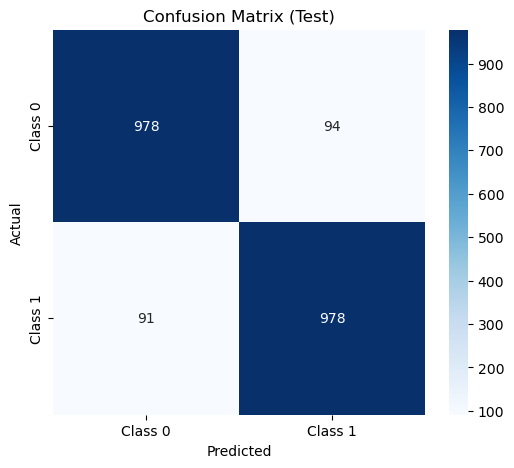

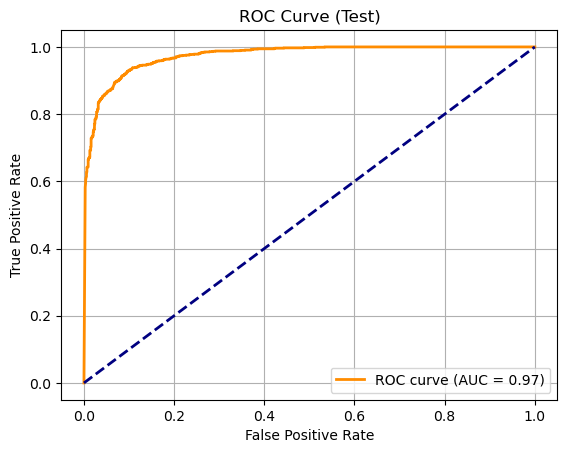

In [ ]:

# Helper function to generate evaluation metrics
def evaluate_and_plot(model, X, y, dataset_name):
    y_prob = model.predict(X).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # Classification report
    print(f"\n=== Classification Report ({dataset_name}) ===")
    print(classification_report(y, y_pred,digits=6))

    # Confusion matrix
    print(f"\n=== Confusion Matrix ({dataset_name}) ===")
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve ({dataset_name})')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()


# === Evaluate on Train, Validation, and Test ===
evaluate_and_plot(model, X_train_dense, y_train, "Train")
evaluate_and_plot(model, X_val_dense, y_val, "Validation")
evaluate_and_plot(model, X_test_dense, y_test, "Test")

### Clear Final Backend Session

In [ ]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()